# Notebook para el Asistente Virtual

### Elaborado por Alvaro Zambrana Sejas
### Universidad Mayor de San Simón
### 2024

Entrenamiento local con YOLO utilizando un dataset personalizado.

Requirements:
- Anaconda
- Python 3.10 

Configurar:
```
conda create -n copiloto-virtual python=3.10
conda activate copiloto-virtual
``` 

In [1]:
!python --version

Python 3.10.16


In [2]:
!nvidia-smi

Thu Mar 13 18:13:14 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 572.60                 Driver Version: 572.60         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090      WDDM  |   00000000:01:00.0  On |                  N/A |
| 36%   37C    P8             30W /  350W |    1608MiB /  24576MiB |     11%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Configurar el entorno

In [3]:
import os
%cd ..

HOME = os.getcwd()
parent_dir = os.path.dirname(HOME)
print(f'HOME: {HOME}')

import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition
HOME: C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition


C:\apps\anaconda3\envs\copiloto-virtual\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [4]:
!pip uninstall -y torch torchvision torchaudio


Found existing installation: torch 2.5.1+cu124
Uninstalling torch-2.5.1+cu124:
  Successfully uninstalled torch-2.5.1+cu124
Found existing installation: torchvision 0.20.1+cu124
Uninstalling torchvision-0.20.1+cu124:
  Successfully uninstalled torchvision-0.20.1+cu124
Found existing installation: torchaudio 2.5.1+cu124
Uninstalling torchaudio-2.5.1+cu124:
  Successfully uninstalled torchaudio-2.5.1+cu124


You can safely remove it manually.


In [5]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126


Looking in indexes: https://download.pytorch.org/whl/cu126
  Using cached https://download.pytorch.org/whl/cu126/torch-2.6.0%2Bcu126-cp310-cp310-win_amd64.whl.metadata (28 kB)
  Using cached https://download.pytorch.org/whl/cu126/torchvision-0.21.0%2Bcu126-cp310-cp310-win_amd64.whl.metadata (6.3 kB)
  Using cached https://download.pytorch.org/whl/cu126/torchaudio-2.6.0%2Bcu126-cp310-cp310-win_amd64.whl.metadata (6.8 kB)
Using cached https://download.pytorch.org/whl/cu126/torch-2.6.0%2Bcu126-cp310-cp310-win_amd64.whl (2496.1 MB)
Using cached https://download.pytorch.org/whl/cu126/torchvision-0.21.0%2Bcu126-cp310-cp310-win_amd64.whl (6.1 MB)
Using cached https://download.pytorch.org/whl/cu126/torchaudio-2.6.0%2Bcu126-cp310-cp310-win_amd64.whl (4.2 MB)


In [6]:

import torch
print(torch.cuda.is_available())  # Should return True
print(torch.cuda.get_device_name(0))
print(torch.cuda.current_device())
print(torch.__version__)

True
NVIDIA GeForce RTX 3090
0
2.6.0+cu126


In [7]:
!pip uninstall -y ultralytics

Found existing installation: ultralytics 8.3.89
Uninstalling ultralytics-8.3.89:
  Successfully uninstalled ultralytics-8.3.89


In [8]:
!pip install ultralytics

  Using cached ultralytics-8.3.89-py3-none-any.whl.metadata (35 kB)
Using cached ultralytics-8.3.89-py3-none-any.whl (932 kB)


In [9]:

import ultralytics
ultralytics.checks()

Ultralytics 8.3.89  Python-3.10.16 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3090, 24575MiB)
Setup complete  (12 CPUs, 31.9 GB RAM, 935.2/953.0 GB disk)


In [10]:
!pip install huggingface_hub

In [11]:
!yolo -version

8.3.89


# Inferencia utilizando el model de YOLO11 pre-entrenado

In [13]:
!cd {HOME}

!yolo task=detect mode=predict conf=0.25 save=True model={HOME}/weights/yolo11n.pt source="{HOME}\\dataset\\processed\\yolo_signals_cbba_with_augmented_data\\test\\images\\2024_09_08_17_28_09_150_-0400_1280x1280.right-region.jpg" device=0 project="resultados\\YOLO11" name="prueba_inferencia" exist_ok=True

Ultralytics 8.3.89 ðŸš€ Python-3.10.16 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3090, 24575MiB)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

image 1/1 C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition\dataset\processed\yolo_signals_cbba_with_augmented_data\test\images\2024_09_08_17_28_09_150_-0400_1280x1280.right-region.jpg: 640x640 1 person, 3 cars, 1 bus, 16.3ms
Speed: 4.3ms preprocess, 16.3ms inference, 91.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to resultados\YOLO11\prueba_inferencia
ðŸ’¡ Learn more at https://docs.ultralytics.com/modes/predict


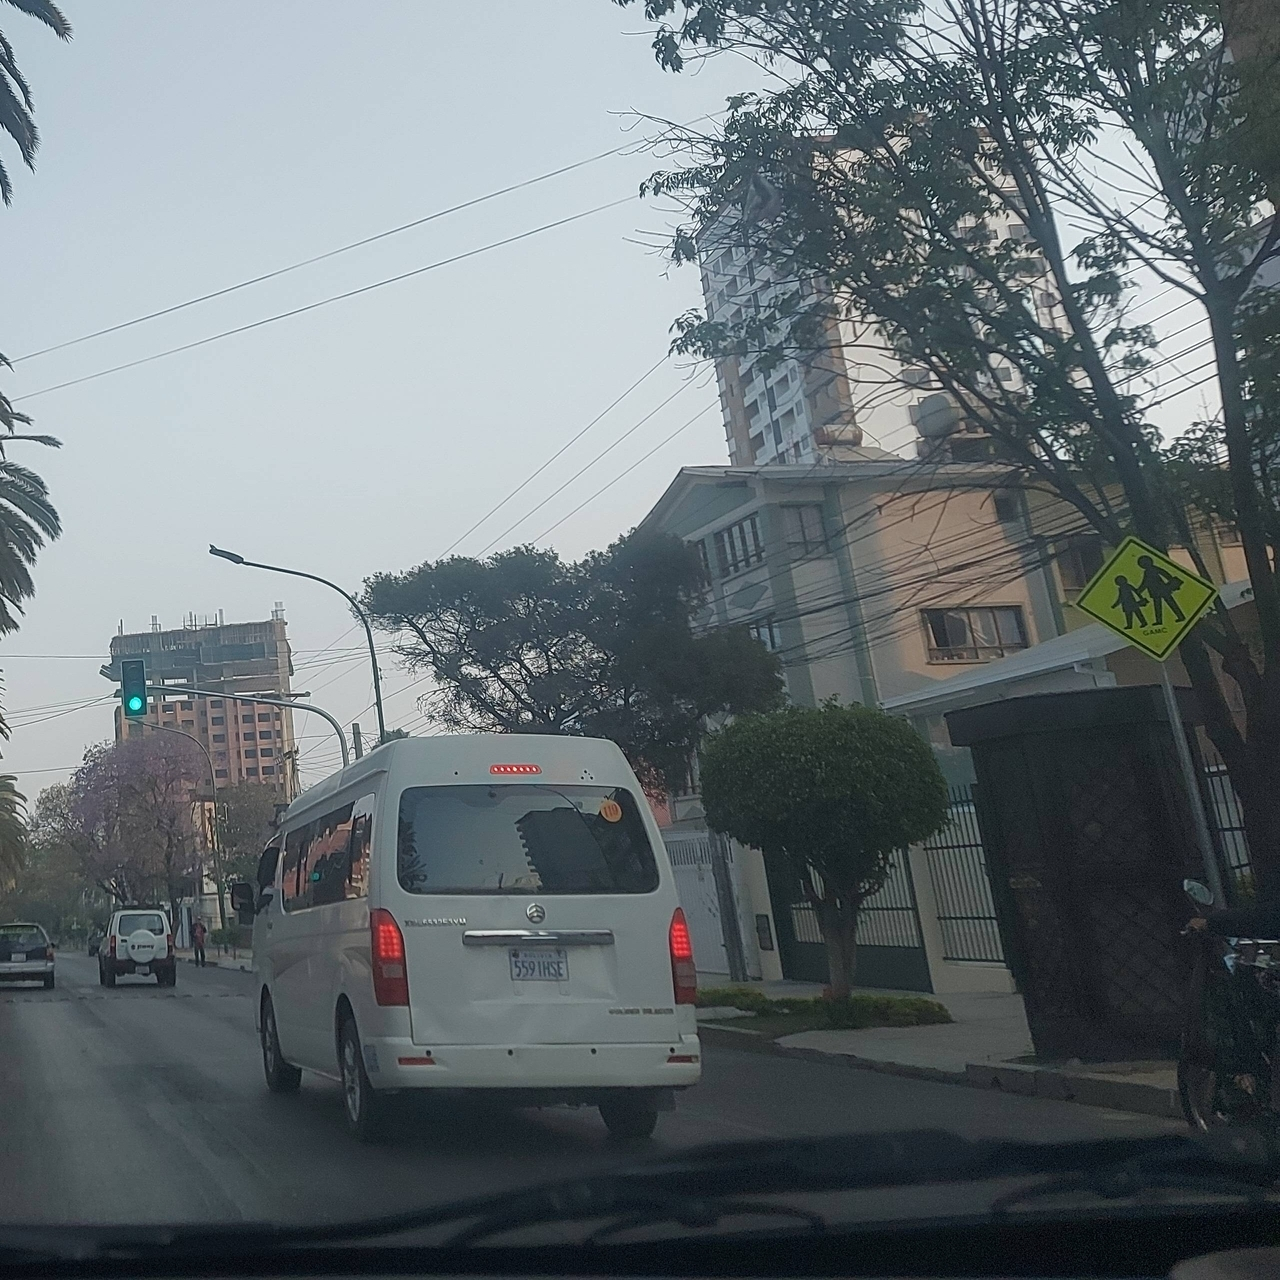

In [15]:
from IPython.display import Image

Image(filename=f"{HOME}\\dataset\\processed\\yolo_signals_cbba_with_augmented_data\\test\\images\\2024_09_08_17_28_09_150_-0400_1280x1280.right-region.jpg", height=640)

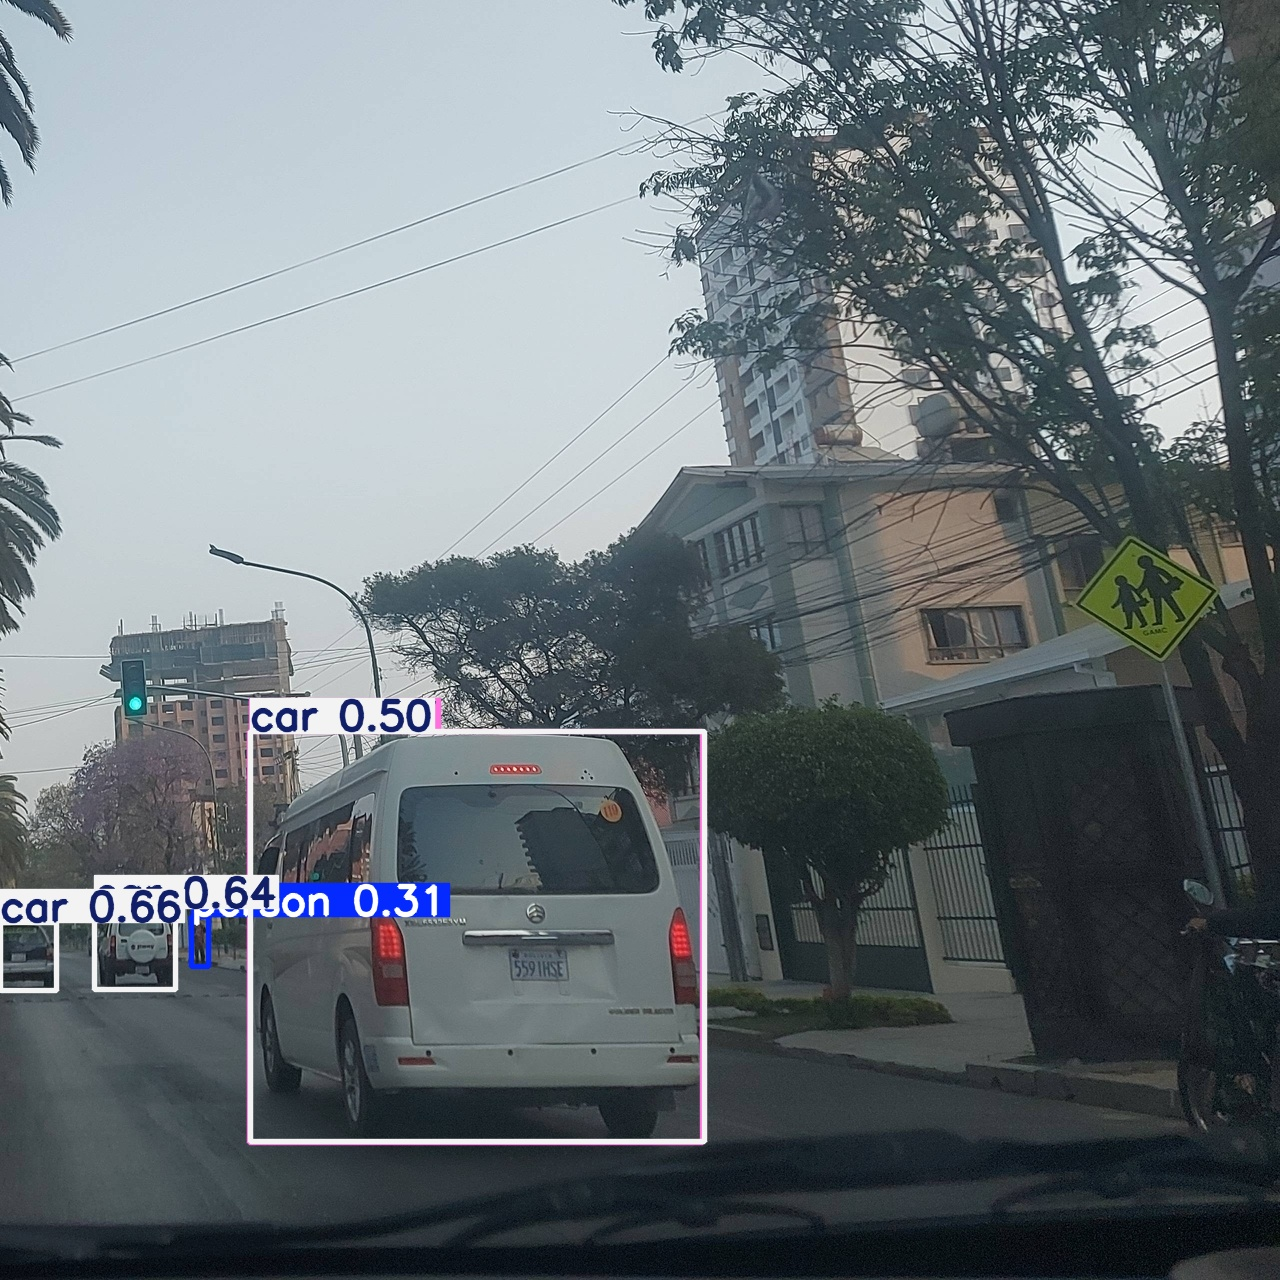

In [16]:
from IPython.display import Image

# Display the detected image
Image(filename=f"{HOME}\\resultados\YOLO11\prueba_inferencia\\2024_09_08_17_28_09_150_-0400_1280x1280.right-region.jpg", height=640)

# Entrenamiento con Fine Tuning de YOLO11 utilizando un conjunto de datos personalizado

In [17]:
import torch
print(torch.cuda.is_available())

True


In [18]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Wed_Aug_14_10:26:51_Pacific_Daylight_Time_2024
Cuda compilation tools, release 12.6, V12.6.68
Build cuda_12.6.r12.6/compiler.34714021_0


In [19]:
torch.version.cuda

'12.6'

In [20]:
import ultralytics

ultralytics.checks()

Ultralytics 8.3.89  Python-3.10.16 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3090, 24575MiB)
Setup complete  (12 CPUs, 31.9 GB RAM, 935.2/953.0 GB disk)


In [21]:
!pip install albumentations==1.4

In [23]:
os.environ['YOLO_VERBOSE'] = 'True'
os.environ['NO_ALBUMENTATIONS_UPDATE'] = '1'

%cd {HOME}

!yolo task=detect mode=train epochs=10 batch=16 plots=True model={HOME}/weights/yolo11n.pt data={HOME}/dataset/processed/yolo_signals_cbba_with_augmented_data/data.yaml device=0 lr0=1e-4 imgsz=640 project="resultados\\YOLO11" name="10_epochs" exist_ok=True

C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition
Ultralytics 8.3.89 ðŸš€ Python-3.10.16 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3090, 24575MiB)
engine\trainer: task=detect, mode=train, model=C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition/weights/yolo11n.pt, data=C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition/dataset/processed/yolo_signals_cbba_with_augmented_data/data.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=resultados\\YOLO11, name=10_epochs, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=


train: Scanning C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition\dataset\processed\yolo_signals_cbba_with_augmented_data\train\labels.cache... 4881 images, 168 backgrounds, 0 corrupt: 100%|##########| 4881/4881 [00:00<?, ?it/s]
train: Scanning C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition\dataset\processed\yolo_signals_cbba_with_augmented_data\train\labels.cache... 4881 images, 168 backgrounds, 0 corrupt: 100%|##########| 4881/4881 [00:00<?, ?it/s]

val: Scanning C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition\dataset\processed\yolo_signals_cbba_with_augmented_data\val\labels.cache... 235 images, 0 backgrounds, 0 corrupt: 100%|##########| 235/235 [00:00<?, ?it/s]
val: Scanning C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition\dataset\processed\yolo_signals_cbba_with_augmented_data\val\labels.cache... 235 images, 0 backgrounds, 0 corrupt: 100%|##########| 235/235 [00:00<?, ?it/s]

  0

In [24]:
os.environ['YOLO_VERBOSE'] = 'True'
os.environ['NO_ALBUMENTATIONS_UPDATE'] = '1'

%cd {HOME}

!yolo task=detect mode=train epochs=300 batch=16 plots=True model={HOME}/weights/yolo11n.pt data={HOME}/dataset/processed/yolo_signals_cbba_with_augmented_data/data.yaml device=0 lr0=1e-4 patience=20 imgsz=640 project="resultados\\YOLO11" name="300_epochs" exist_ok=True


C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition
Ultralytics 8.3.89 ðŸš€ Python-3.10.16 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3090, 24575MiB)
engine\trainer: task=detect, mode=train, model=C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition/weights/yolo11n.pt, data=C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition/dataset/processed/yolo_signals_cbba_with_augmented_data/data.yaml, epochs=300, time=None, patience=20, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=resultados\\YOLO11, name=300_epochs, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half


train: Scanning C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition\dataset\processed\yolo_signals_cbba_with_augmented_data\train\labels.cache... 4881 images, 168 backgrounds, 0 corrupt: 100%|##########| 4881/4881 [00:00<?, ?it/s]
train: Scanning C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition\dataset\processed\yolo_signals_cbba_with_augmented_data\train\labels.cache... 4881 images, 168 backgrounds, 0 corrupt: 100%|##########| 4881/4881 [00:00<?, ?it/s]

val: Scanning C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition\dataset\processed\yolo_signals_cbba_with_augmented_data\val\labels.cache... 235 images, 0 backgrounds, 0 corrupt: 100%|##########| 235/235 [00:00<?, ?it/s]
val: Scanning C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition\dataset\processed\yolo_signals_cbba_with_augmented_data\val\labels.cache... 235 images, 0 backgrounds, 0 corrupt: 100%|##########| 235/235 [00:00<?, ?it/s]

  0

# Pruebas de inferencia con el modelo entrenado

In [25]:
!yolo task=detect mode=predict conf=0.25 imgsz=640 save=True show=True model={HOME}\resultados\YOLO11\300_epochs\weights\best.pt source={HOME}\dataset\processed\yolo_signals_cbba_with_augmented_data\test\images\ device=0 project="resultados\\YOLO11" name="prueba_inferencia_300_epochs" exist_ok=True

WARNING âš ï¸� Environment does not support cv2.imshow() or PIL Image.show()
OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window.cpp:1301: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvShowImage'

Ultralytics 8.3.89 ðŸš€ Python-3.10.16 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3090, 24575MiB)
YOLO11n summary (fused): 100 layers, 2,585,077 parameters, 0 gradients, 6.3 GFLOPs

image 1/116 C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition\dataset\processed\yolo_signals_cbba_with_augmented_data\test\images\2024_08_18_17_40_52_601_-0400_1280x1280.left-region.jpg: 640x640 1 zona-escolar, 1 prohibido-girar-izquierda, 24.5ms
image 2/116 C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition\dataset\processed\yolo_signals_

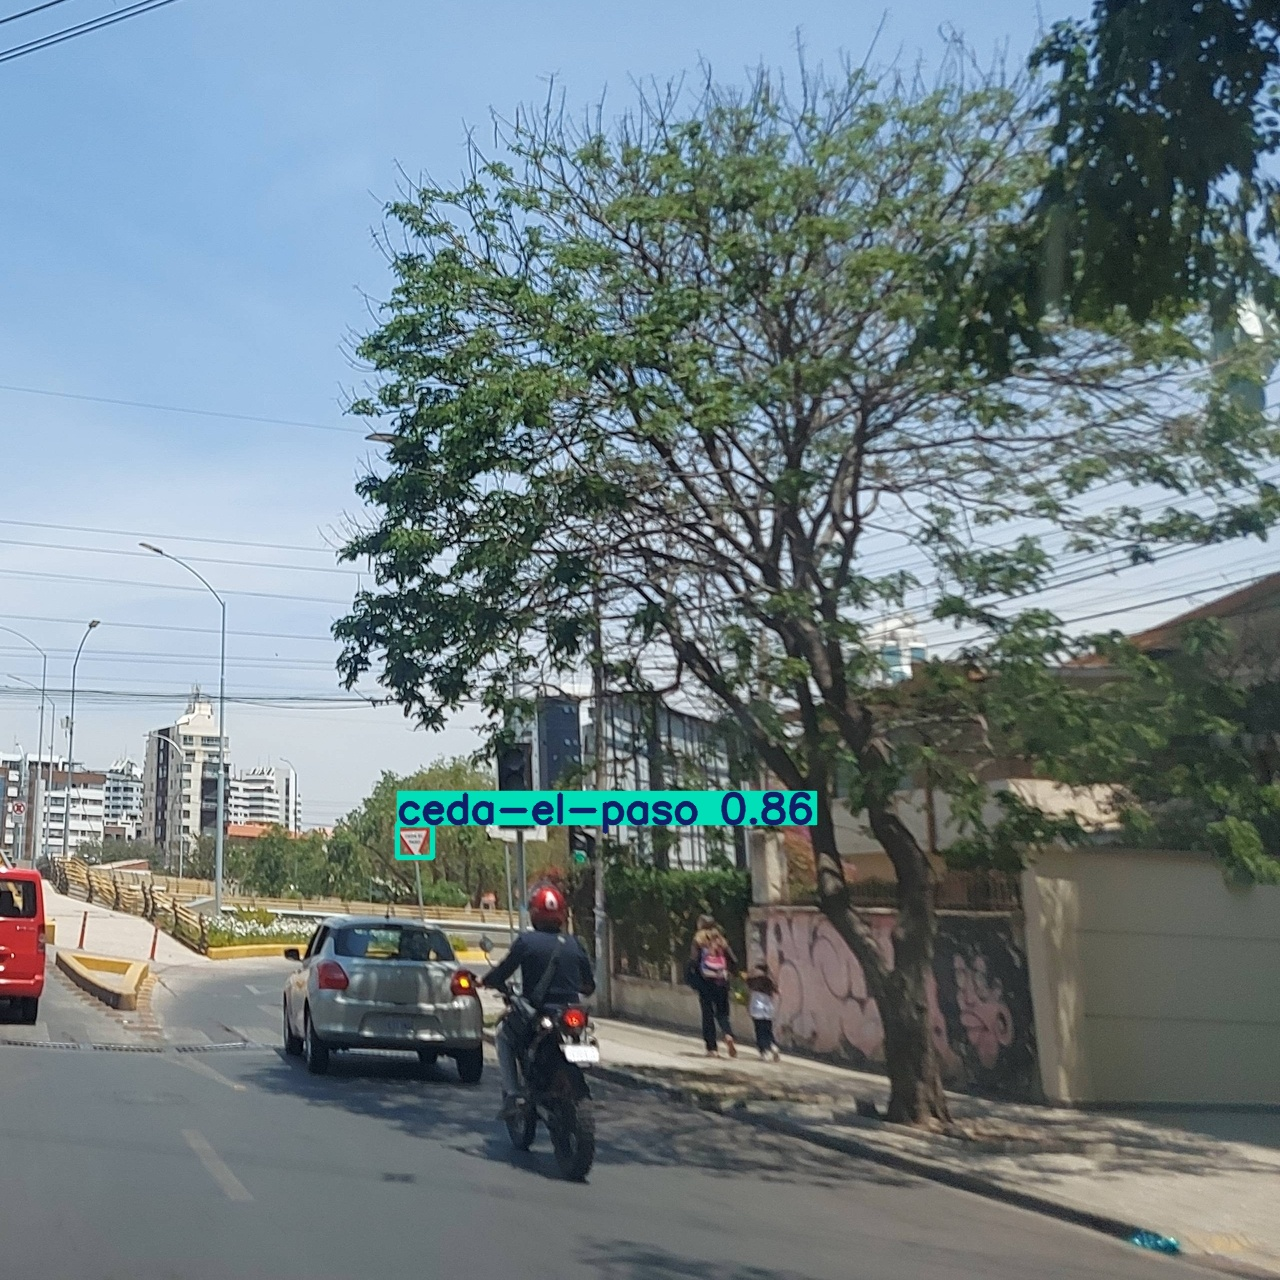

In [26]:
from IPython.display import Image
Image(filename=f"{HOME}\\resultados\YOLO11\\prueba_inferencia_300_epochs\\2024_10_01_12_40_45_425_-0400_1280x1280.right-region.jpg", height=600)

## Matrices de Confusión

C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition


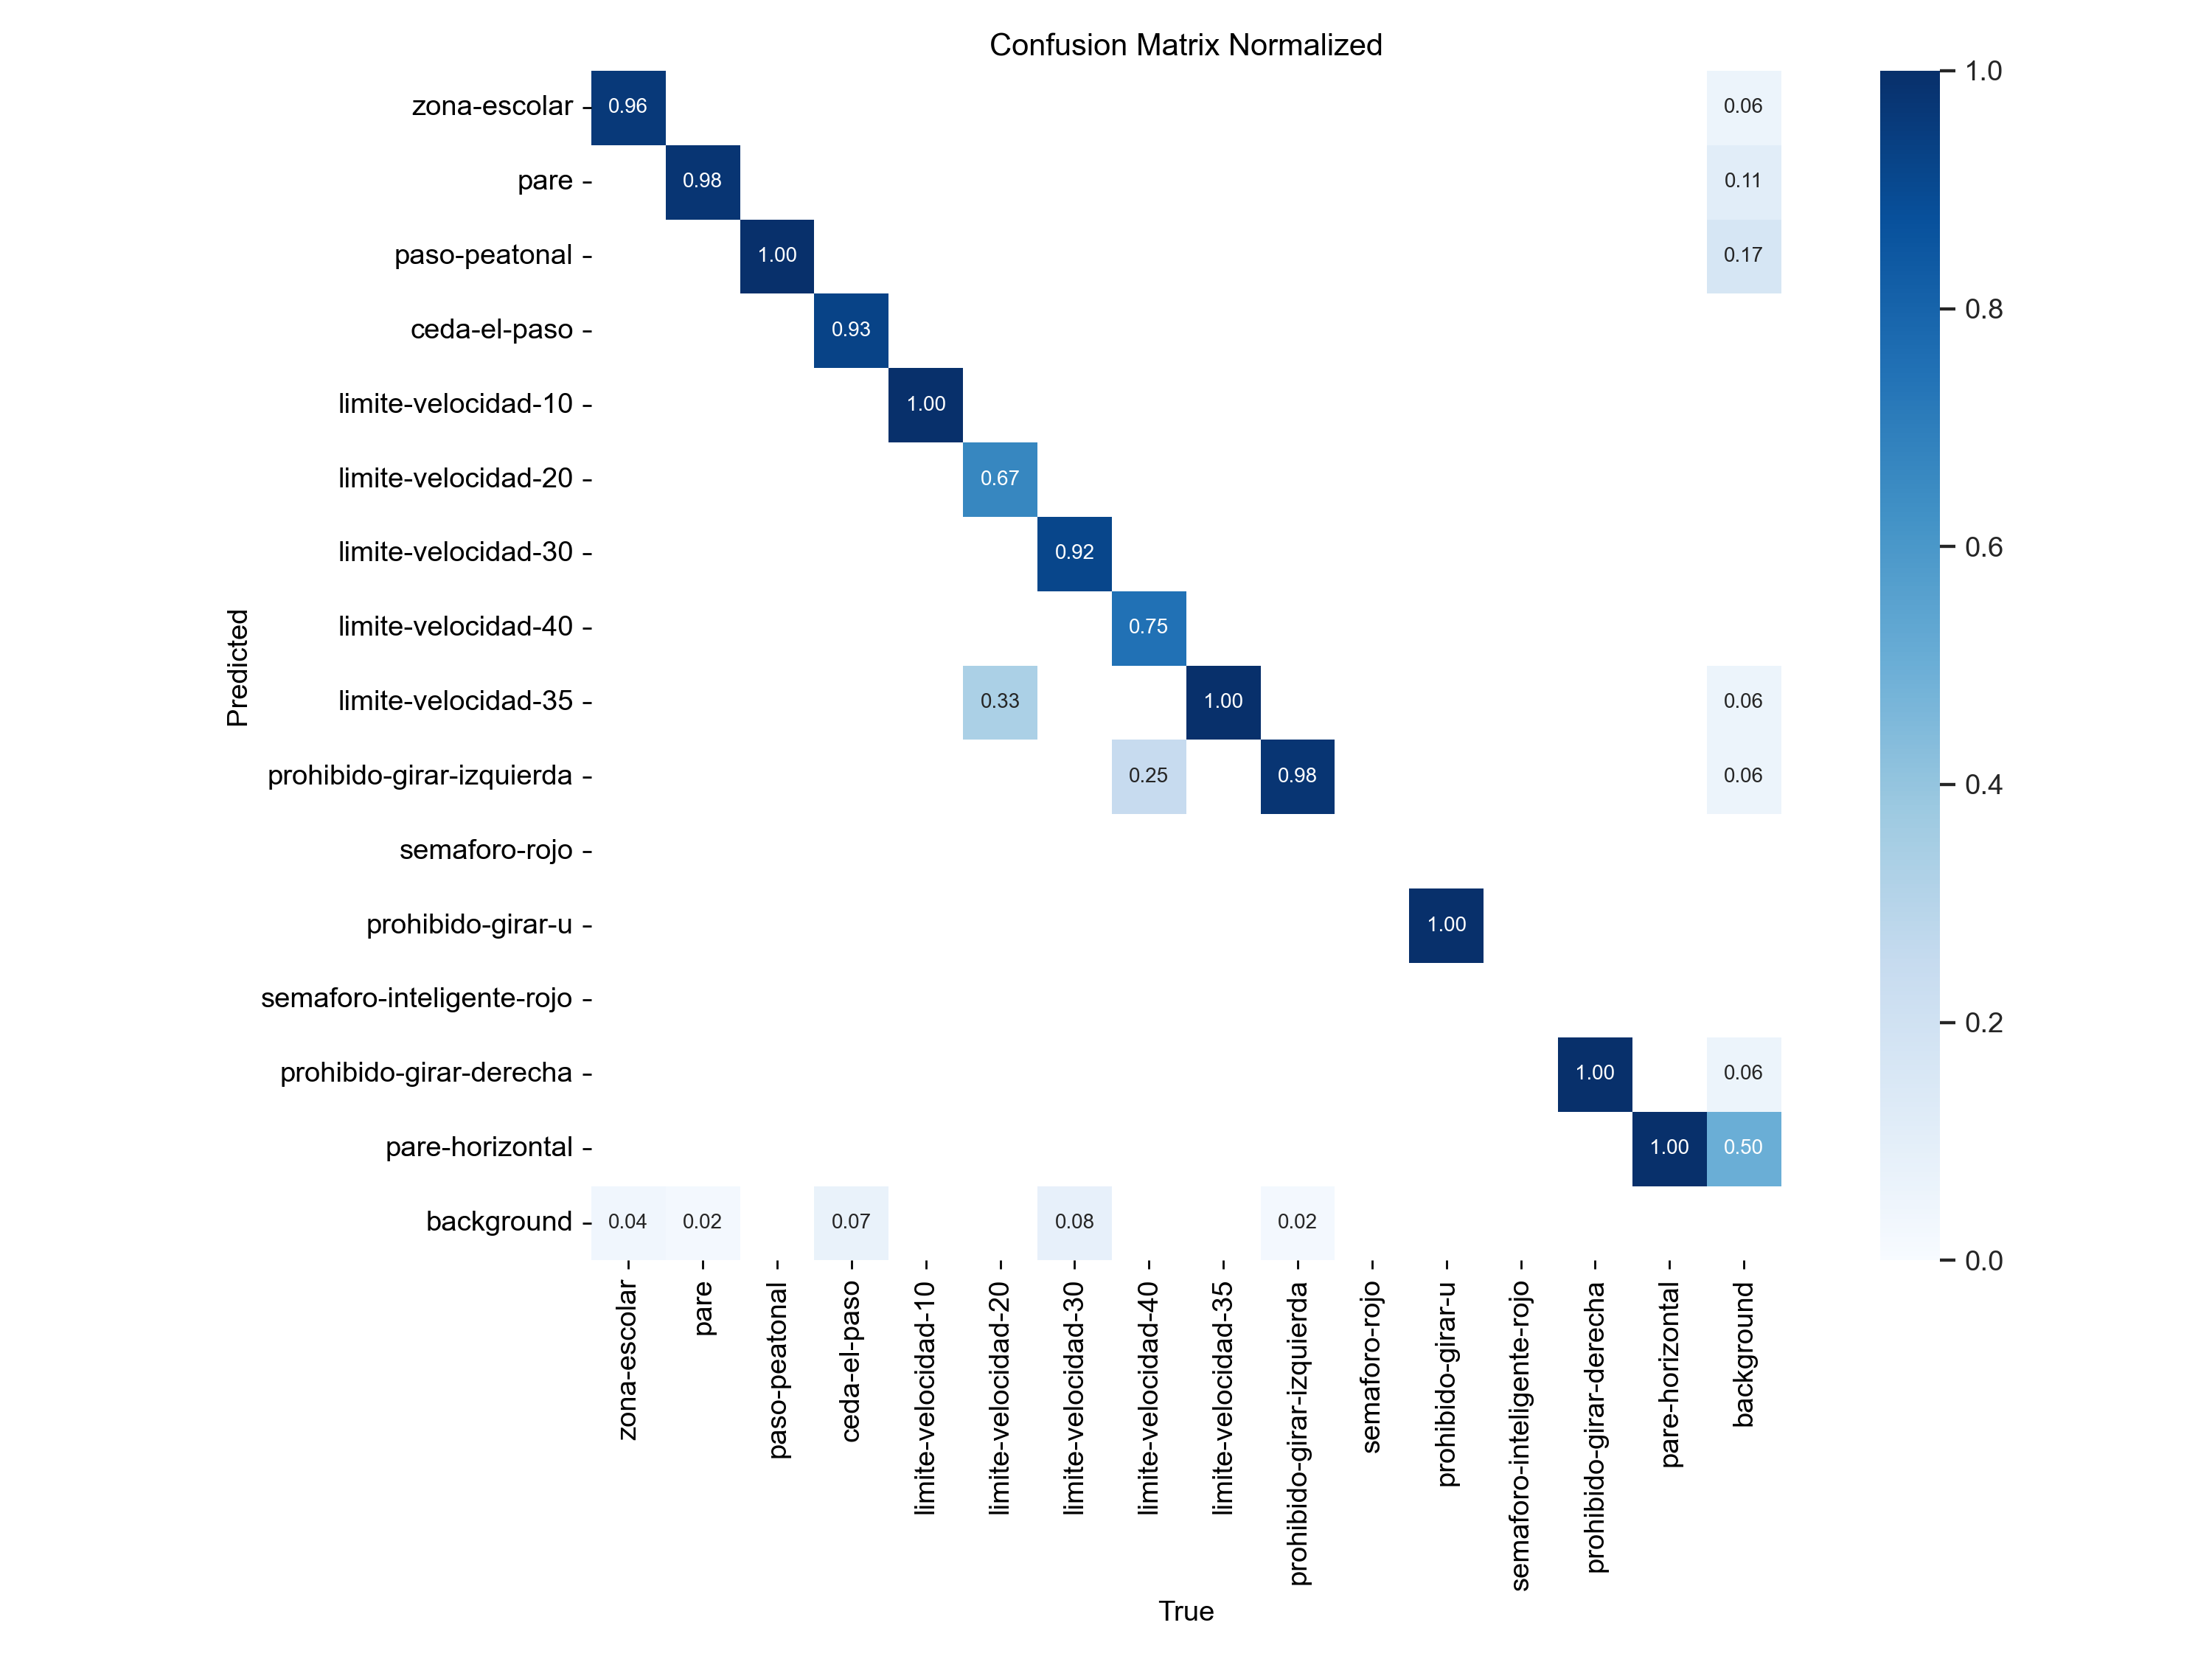

In [27]:
%cd {HOME}
Image(filename=f'{HOME}\\resultados\\YOLO11\\300_epochs\\confusion_matrix_normalized.png', width=600)

## Exportar el mejor modelo

In [29]:
!yolo export model={HOME}/resultados/YOLO11/300_epochs/weights/best.pt format=tflite

Ultralytics 8.3.89 ðŸš€ Python-3.10.16 torch-2.6.0+cu126 CPU (Intel Core(TM) i7-8700 3.20GHz)
YOLO11n summary (fused): 100 layers, 2,585,077 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from 'C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition\resultados\YOLO11\300_epochs\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 19, 8400) (5.2 MB)

TensorFlow SavedModel: starting export with tensorflow 2.18.0...

ONNX: starting export with onnx 1.17.0 opset 19...
ONNX: slimming with onnxslim 0.1.31...
ONNX: export success âœ… 1.7s, saved as 'C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition\resultados\YOLO11\300_epochs\weights\best.onnx' (10.2 MB)
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.26.3...
TensorFlow SavedModel: export success âœ… 41.0s, saved as 'C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition\resultados\YOLO11\300_epochs\weights\best_saved_model' (26.6 MB)


I0000 00:00:1741912598.768522    7612 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1741912598.769645    7612 single_machine.cc:361] Starting new session
W0000 00:00:1741912599.911920    7612 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1741912599.912445    7612 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1741912601.102009    7612 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1741912601.102157    7612 single_machine.cc:361] Starting new session
W0000 00:00:1741912601.906330    7612 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1741912601.906387    7612 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
